# 03. Trajectory Construction & Leakage-Safe Formulation
**Project:** Where Will This Vessel Be in 4–6 Hours?  
**Author:** Praneeth (ED23B032)  
**Assignment:** Blurgs.ai Take-Home  

---

### Key Requirements Addressed in this Notebook
1. **Input History Window:** Extract approximately 4 hours of historical observations up to forecast origin $T$ ($[T - 4\text{h}, T]$).
2. **Future Targets:** Link actual vessel positions at $T + 4\text{ hours}$ and $T + 6\text{ hours}$.
3. **Irregular Sampling Tolerances:**
   - Minimum history points: $\ge 10$ observations.
   - History coverage tolerance: at least $3.5\text{ hours}$ of span.
   - Target timestamp tolerance: $\le 15\text{ minutes}$ around nominal $+4\text{h}$ and $+6\text{h}$.
4. **Data Leakage Prevention:**
   - **No random shuffling:** Randomly splitting points or windows from the same time period allows future trajectory shapes to leak into training.
   - **Strict chronological split:** Windows are partitioned by origin timestamp $T$:
     $$\text{Train } (T \le 13:00) \quad\longrightarrow\quad \text{Val } (13:00 < T \le 15:15) \quad\longrightarrow\quad \text{Test } (T > 15:15)$$
     The test set represents the actual chronological future and remains completely sequestered.
5. **Local Metric Tangent Plane:**
   - Converting spherical $(\text{lat}, \text{lon})$ to local East-North $(x, y)$ in metres centered at each trajectory origin $(lat_0, lon_0)$.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.trajectories import extract_forecasting_windows, chronological_dataset_split
from src.coordinates import wgs84_to_local_enu, local_enu_to_wgs84, compute_geodesic_distance_km

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Modules loaded.")


Modules loaded.


In [2]:
clean_path = os.path.join(project_root, "data", "processed", "ais_cleaned_trajectories.parquet")
df_clean = pd.read_parquet(clean_path)
df_clean["base_date_time"] = pd.to_datetime(df_clean["base_date_time"])

print(f"Loaded cleaned records: {len(df_clean):,}")
print(f"Cleaned continuous trajectories: {df_clean['trajectory_id'].nunique():,}")


Loaded cleaned records: 60,976
Cleaned continuous trajectories: 101


In [3]:
windows = extract_forecasting_windows(
    df_clean,
    history_hours=4.0,
    forecast_horizons=[4.0, 6.0],
    min_history_points=10,
    history_span_tolerance_hours=0.5,
    target_tolerance_minutes=15.0,
    origin_step_hours=1.5
)

print(f"Extracted valid evaluation windows: {len(windows):,}")


Extracted valid evaluation windows: 422


In [4]:
train_w, val_w, test_w, split_summary = chronological_dataset_split(
    windows, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15
)

split_df = pd.DataFrame([
    {"Split": "Train", "Count": split_summary["train_count"], "Pct": f"{split_summary['train_pct']:.1f}%", "Origin Range": f"{split_summary['train_t_min']} to {split_summary['train_t_max']}"},
    {"Split": "Validation", "Count": split_summary["val_count"], "Pct": f"{split_summary['val_pct']:.1f}%", "Origin Range": f"{split_summary['val_t_min']} to {split_summary['val_t_max']}"},
    {"Split": "Test (Unseen)", "Count": split_summary["test_count"], "Pct": f"{split_summary['test_pct']:.1f}%", "Origin Range": f"{split_summary['test_t_min']} to {split_summary['test_t_max']}"}
])

print("=== LEAKAGE-SAFE CHRONOLOGICAL SPLIT ===")
print(split_df.to_string(index=False))


=== LEAKAGE-SAFE CHRONOLOGICAL SPLIT ===
        Split  Count   Pct                               Origin Range
        Train    295 69.9% 2024-01-01 04:00:01 to 2024-01-01 13:00:03
   Validation     63 14.9% 2024-01-01 13:00:04 to 2024-01-01 15:11:35
Test (Unseen)     64 15.2% 2024-01-01 15:23:13 to 2024-01-01 17:57:19


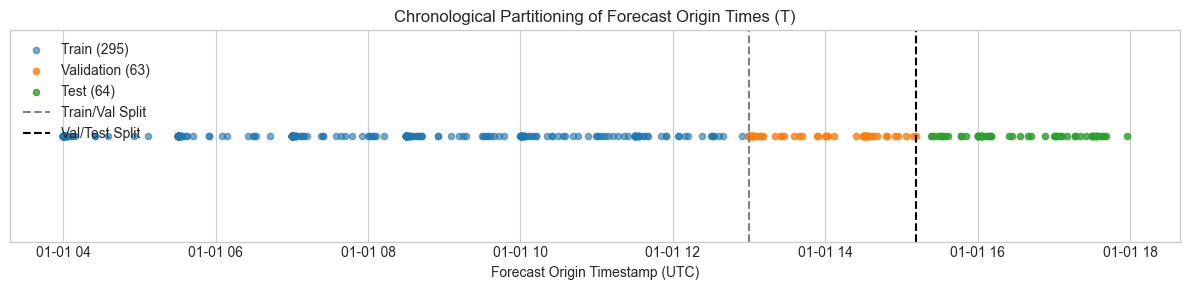

In [5]:
origins_train = [w.origin_time for w in train_w]
origins_val = [w.origin_time for w in val_w]
origins_test = [w.origin_time for w in test_w]

fig, ax = plt.subplots(figsize=(12, 3))

ax.scatter(origins_train, np.zeros(len(origins_train)), color='#1f77b4', s=20, alpha=0.6, label=f'Train ({len(train_w)})')
ax.scatter(origins_val, np.zeros(len(origins_val)), color='#ff7f0e', s=20, alpha=0.8, label=f'Validation ({len(val_w)})')
ax.scatter(origins_test, np.zeros(len(origins_test)), color='#2ca02c', s=20, alpha=0.8, label=f'Test ({len(test_w)})')

# Split boundary lines
ax.axvline(max(origins_train), color='gray', linestyle='--', label='Train/Val Split')
ax.axvline(max(origins_val), color='black', linestyle='--', label='Val/Test Split')

ax.set_yticks([])
ax.set_title("Chronological Partitioning of Forecast Origin Times (T)", fontsize=12)
ax.set_xlabel("Forecast Origin Timestamp (UTC)")
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig(os.path.join(project_root, "results", "figures", "trajectory_window_split.png"), dpi=150)
plt.show()


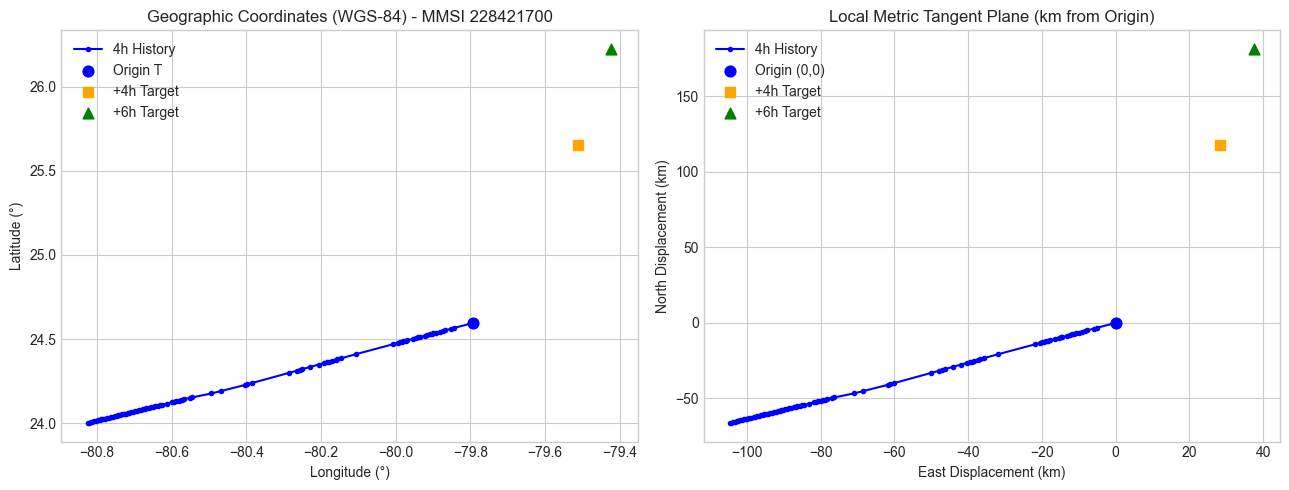

Roundtrip projection precision error: 0.0000 millimeters


In [6]:
# Inspect sample window in local East-North metric coordinates
sample = windows[0]
hist = sample.history_df

lat0 = sample.origin_lat
lon0 = sample.origin_lon

x_hist, y_hist = wgs84_to_local_enu(hist["latitude"].values, hist["longitude"].values, lat0, lon0)
x_4h, y_4h = wgs84_to_local_enu(sample.target_4h["lat"], sample.target_4h["lon"], lat0, lon0)
x_6h, y_6h = wgs84_to_local_enu(sample.target_6h["lat"], sample.target_6h["lon"], lat0, lon0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Geographic space
ax1.plot(hist["longitude"], hist["latitude"], 'b.-', label='4h History')
ax1.scatter([lon0], [lat0], color='blue', s=60, label='Origin T')
ax1.scatter([sample.target_4h["lon"]], [sample.target_4h["lat"]], color='orange', s=60, marker='s', label='+4h Target')
ax1.scatter([sample.target_6h["lon"]], [sample.target_6h["lat"]], color='green', s=60, marker='^', label='+6h Target')
ax1.set_title(f"Geographic Coordinates (WGS-84) - MMSI {sample.mmsi}")
ax1.set_xlabel("Longitude (°)")
ax1.set_ylabel("Latitude (°)")
ax1.legend()

# Local metric space
ax2.plot(x_hist / 1000.0, y_hist / 1000.0, 'b.-', label='4h History')
ax2.scatter([0], [0], color='blue', s=60, label='Origin (0,0)')
ax2.scatter([x_4h / 1000.0], [y_4h / 1000.0], color='orange', s=60, marker='s', label='+4h Target')
ax2.scatter([x_6h / 1000.0], [y_6h / 1000.0], color='green', s=60, marker='^', label='+6h Target')
ax2.set_title("Local Metric Tangent Plane (km from Origin)")
ax2.set_xlabel("East Displacement (km)")
ax2.set_ylabel("North Displacement (km)")
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(project_root, "results", "figures", "metric_coordinate_demo.png"), dpi=150)
plt.show()

# Verification of inversion
lat_inv, lon_inv = local_enu_to_wgs84(x_4h, y_4h, lat0, lon0)
diff_km = compute_geodesic_distance_km(sample.target_4h["lat"], sample.target_4h["lon"], lat_inv, lon_inv)
print(f"Roundtrip projection precision error: {diff_km * 1e6:.4f} millimeters")


In [7]:
win_dicts = [w.to_dict() for w in windows]
win_df = pd.DataFrame(win_dicts)

# Mark splits
val_ids = set(w.sample_id for w in val_w)
test_ids = set(w.sample_id for w in test_w)
win_df["split"] = "train"
win_df.loc[win_df["sample_id"].isin(val_ids), "split"] = "val"
win_df.loc[win_df["sample_id"].isin(test_ids), "split"] = "test"

output_windows = os.path.join(project_root, "data", "processed", "forecasting_windows.parquet")
win_df.to_parquet(output_windows, index=False, compression="zstd")
print(f"Saved {len(win_df):,} forecasting windows metadata to: {output_windows}")


Saved 422 forecasting windows metadata to: C:\Users\girik\.gemini\antigravity\scratch\Blurgs.ai_Assignment_ED23B032\data\processed\forecasting_windows.parquet
